In [1]:
from pathlib import Path
import sys
import os

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
os.chdir(str(project_root))
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from evaluation.benchmark_universeg.benchmark_2d import EvalPipeline2D

# UniverSeg vs Prompt U-Net Comparison

This notebook runs the automated evaluation pipeline to compare the performance of **UniverSeg** and **Prompt-UNet** on 2D datasets.

In [ ]:
pipeline = EvalPipeline2D()

offset = 'offset_5'
p_unet_version = '332'

model_name = 'prompt_unet'
model = 'p_unet_332'
output_name = f"results_{model}_{offset}.pkl"

# model_name = 'universeg'
# output_name = f"results_{model_name}_{offset}.pkl"

data_path = f"data/test_data/2d/{offset}"

results = pipeline.run_full_evaluation(
    data_path=data_path, 
    model_name=model_name,
    p_unet_version=p_unet_version, 
    batch_size = 32,
    output_file=f"evaluation/benchmark_universeg/{output_name}"
)

# Plot results

In [2]:
prompt_pkl_name = "evaluation/benchmark_universeg/results_p_unet_332_offset"
univer_pkl_name = "evaluation/benchmark_universeg/results_universeg_offset"


=== Offset 5 ===
Prompt U-Net


,dice,time,task
count,500.000,500.000,500.000
mean,0.779,1.085,14.620
std,0.183,0.179,13.656
min,0.121,0.517,1.000
25%,0.717,0.995,4.000
50%,0.837,1.064,10.000
75%,0.904,1.134,23.000
max,0.980,3.672,56.000


Universeg


,dice,time,task
count,500.000,500.000,500.000
mean,0.618,1.859,14.620
std,0.245,0.393,13.656
min,0.006,1.001,1.000
25%,0.479,1.567,4.000
50%,0.694,1.822,10.000
75%,0.796,2.096,23.000
max,0.964,3.088,56.000



=== Offset 12 ===
Prompt U-Net


,dice,time,task
count,500.000,500.000,500.000
mean,0.695,1.070,14.818
std,0.207,0.221,13.884
min,0.118,0.240,1.000
25%,0.571,0.988,4.000
50%,0.746,1.064,10.000
75%,0.862,1.142,23.000
max,0.985,3.628,55.000


Universeg


,dice,time,task
count,500.000,500.000,500.000
mean,0.598,1.844,14.818
std,0.261,0.472,13.884
min,0.000,0.526,1.000
25%,0.443,1.542,4.000
50%,0.681,1.790,10.000
75%,0.797,2.100,23.000
max,0.960,5.289,55.000


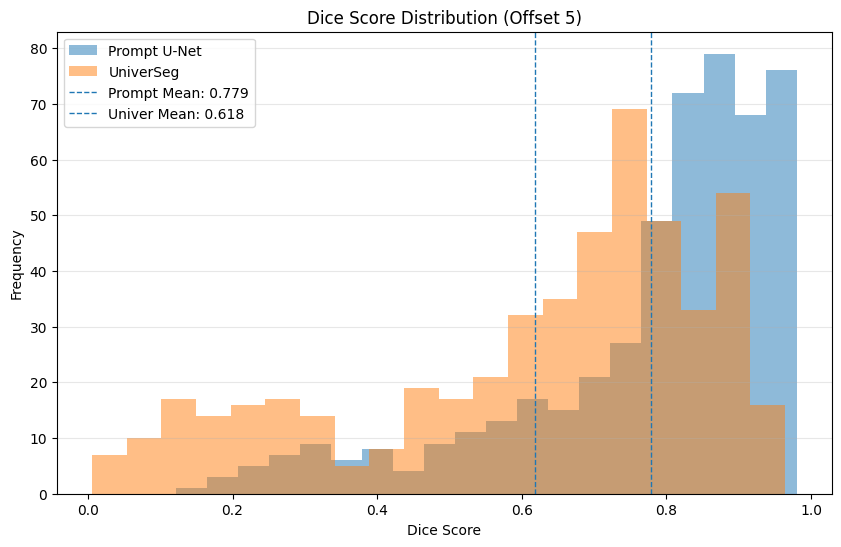

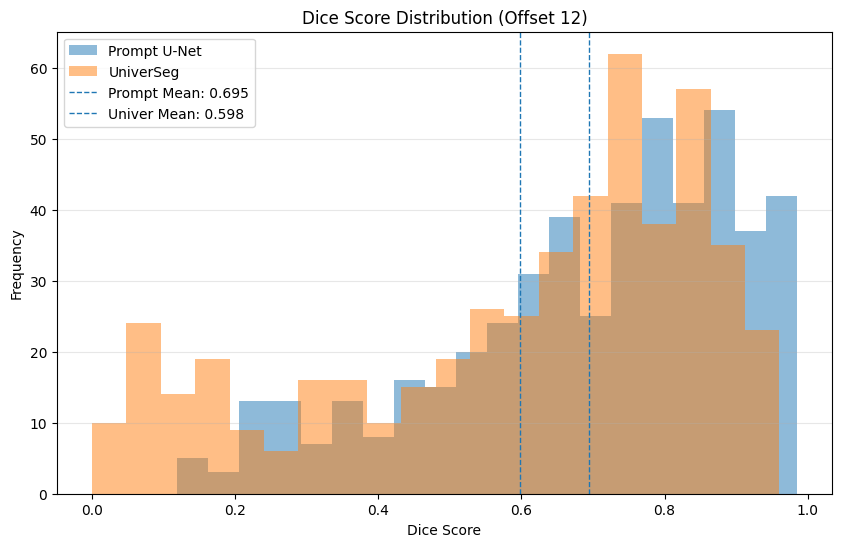

C:\Users\Paul\AppData\Local\Temp\ipykernel_6092\403010865.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


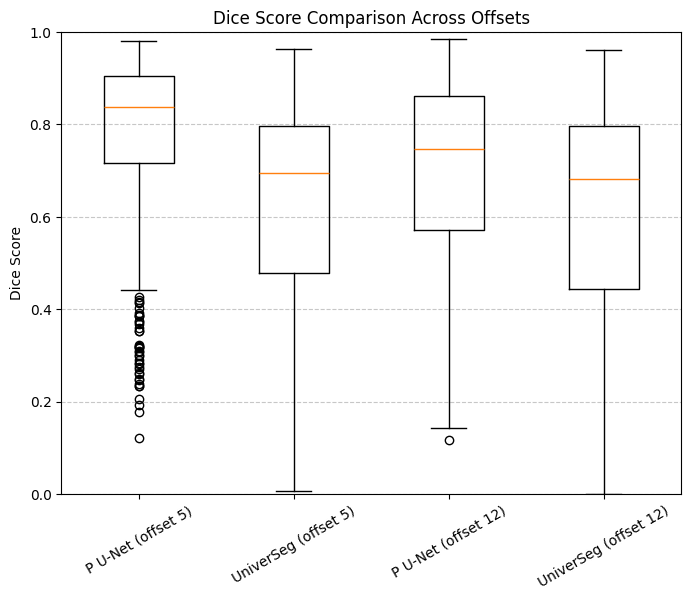

In [4]:
import pandas as pd
pd.set_option('display.float_format', '{:.3f}'.format)
import matplotlib.pyplot as plt

offsets = [5, 12]

results = {}

# Load and store results
for offset in offsets:
    prompt = pd.read_pickle(f"{prompt_pkl_name}_{offset}.pkl")
    univer = pd.read_pickle(f"{univer_pkl_name}_{offset}.pkl")

    df_prompt = pd.DataFrame(prompt)
    df_univer = pd.DataFrame(univer)

    print(f"\n=== Offset {offset} ===")
    print("Prompt U-Net")
    display(df_prompt.describe())
    print("Universeg")
    display(df_univer.describe())

    results[offset] = {
        "prompt": df_prompt["dice"],
        "univer": df_univer["dice"]
    }

# ------------------------
# 1. Histograms (per offset)
# ------------------------
for offset in offsets:
    prompt_dices = results[offset]["prompt"]
    univer_dices = results[offset]["univer"]

    plt.figure(figsize=(10, 6))
    plt.hist(prompt_dices, bins=20, alpha=0.5, label='Prompt U-Net')
    plt.hist(univer_dices, bins=20, alpha=0.5, label='UniverSeg')

    plt.axvline(prompt_dices.mean(), linestyle='dashed', linewidth=1,
                label=f'Prompt Mean: {prompt_dices.mean():.3f}')
    plt.axvline(univer_dices.mean(), linestyle='dashed', linewidth=1,
                label=f'Univer Mean: {univer_dices.mean():.3f}')

    plt.title(f"Dice Score Distribution (Offset {offset})")
    plt.xlabel("Dice Score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# ------------------------
# 2. Combined Boxplot
# ------------------------
data = []
labels = []

for offset in offsets:
    data.append(results[offset]["prompt"])
    labels.append(f"P U-Net (offset {offset})")

    data.append(results[offset]["univer"])
    labels.append(f"UniverSeg (offset {offset})")

plt.figure(figsize=(8, 6))
plt.boxplot(data, labels=labels)
plt.ylabel("Dice Score")
plt.ylim(0, 1.0)
plt.title("Dice Score Comparison Across Offsets")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=30)
plt.show()

# Per dataset scores

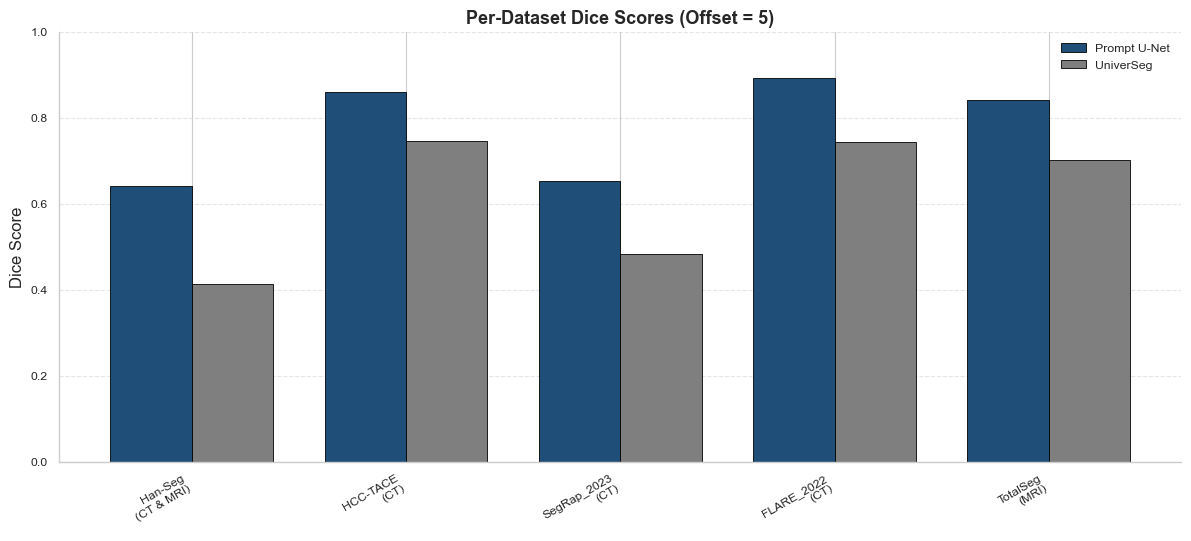

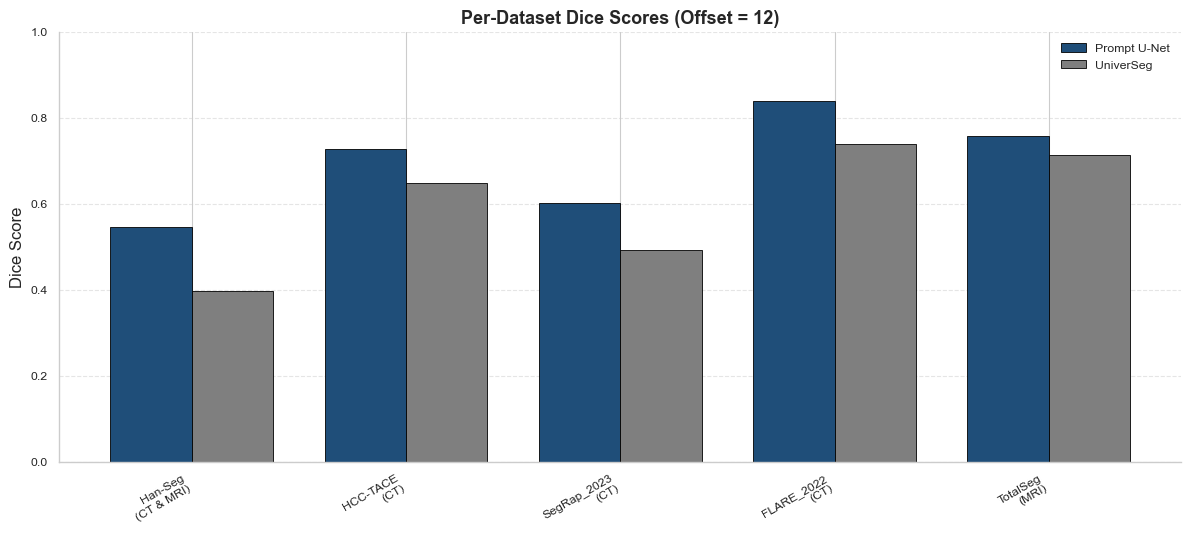

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IEEE-style scientific plotting
sns.set_theme(style="whitegrid", context="paper")

def clean_name(name):
    return name.split("_", 1)[1] if "_" in name else name

dataset_display_names = {
    "flare": "FLARE_2022\n(CT)",
    "han_seg": "Han-Seg\n(CT & MRI)",
    "hcc_tase": "HCC-TACE\n(CT)",
    "seg_rap": "SegRap_2023\n(CT)",
    "total_seg": "TotalSeg\n(MRI)",
}

# Dataset order for x-axis
DS_ORDER = ["han_seg", "hcc_tase", "seg_rap", "flare", "total_seg"]

offsets = [5, 12]

colors = {
    "prompt": "#1f4e79",   # deep blue
    "univer": "#7f7f7f"    # neutral gray
}

for offset in offsets:
    prompt = pd.read_pickle(f"{prompt_pkl_name}_{offset}.pkl")
    univer = pd.read_pickle(f"{univer_pkl_name}_{offset}.pkl")

    df_prompt = pd.DataFrame(prompt)
    df_univer = pd.DataFrame(univer)

    # Clean dataset names
    df_prompt["dataset"] = df_prompt["name"].apply(clean_name)
    df_univer["dataset"] = df_univer["name"].apply(clean_name)

    # Aggregate mean Dice per dataset
    prompt_grouped = (
        df_prompt.groupby("dataset")["dice"]
        .mean()
        .reset_index()
    )

    univer_grouped = (
        df_univer.groupby("dataset")["dice"]
        .mean()
        .reset_index()
    )

    # Merge
    merged = prompt_grouped.rename(columns={"dice": "prompt"}).merge(
        univer_grouped.rename(columns={"dice": "univer"}),
        on="dataset"
    )

    results[offset]["merged"] = merged

    # Order datasets explicitly
    df = merged.set_index("dataset").reindex(DS_ORDER).reset_index()

    # Apply custom x-axis display names
    display_labels = [
        dataset_display_names.get(name, name)
        for name in df["dataset"]
    ]

    x = range(len(df))
    width = 0.38

    fig, ax = plt.subplots(figsize=(12, 5.5))

    ax.bar(
        [i - width/2 for i in x],
        df["prompt"],
        width=width,
        label="Prompt U-Net",
        color=colors["prompt"],
        edgecolor="black",
        linewidth=0.6
    )

    ax.bar(
        [i + width/2 for i in x],
        df["univer"],
        width=width,
        label="UniverSeg",
        color=colors["univer"],
        edgecolor="black",
        linewidth=0.6
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(display_labels, rotation=30, ha="right")

    ax.set_ylabel("Dice Score", fontsize=12)

    ax.set_ylim(0, 1.0)

    # IEEE-style title
    ax.set_title(
        f"Per-Dataset Dice Scores (Offset = {offset})",
        fontsize=13,
        weight="bold"
    )

    # Clean scientific styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", linestyle="--", alpha=0.5)

    ax.legend(frameon=False)

    plt.tight_layout()

    # Optional: save high-quality figure for IEEE Access
    plt.savefig(
        f"dice_scores_offset_{offset}.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [6]:
print("=== Overall Average Dice (across all datasets) ===")
for offset in offsets:
    prompt = pd.read_pickle(f"{prompt_pkl_name}_{offset}.pkl")
    univer = pd.read_pickle(f"{univer_pkl_name}_{offset}.pkl")

    df_p = pd.DataFrame(prompt)
    df_u = pd.DataFrame(univer)

    p_mean = df_p["dice"].mean()
    p_std  = df_p["dice"].std()
    u_mean = df_u["dice"].mean()
    u_std  = df_u["dice"].std()

    print(f"Offset {offset}:")
    print(f"  Prompt U-Net : {p_mean:.3f} ± {p_std:.3f}  (n={len(df_p)})")
    print(f"  UniverSeg    : {u_mean:.3f} ± {u_std:.3f}  (n={len(df_u)})")

=== Overall Average Dice (across all datasets) ===
Offset 5:
  Prompt U-Net : 0.779 ± 0.183  (n=500)
  UniverSeg    : 0.618 ± 0.245  (n=500)
Offset 12:
  Prompt U-Net : 0.695 ± 0.207  (n=500)
  UniverSeg    : 0.598 ± 0.261  (n=500)
